# The Articulation Story — §4.1–4.3 (v3: unsupervised metrics only)
*2026-08-10. Scope = the 1,032 unsupervised construct metrics (humor 284 / creative-writing 369 / math 141 / peer-review 88 / news 150). Supervised benchmarks (hotpot etc.) appear nowhere in this notebook.*

**Glossary:**
- **metric / construct** — one evaluation criterion mined from how communities talk about quality (e.g. 'Compressed, quotable phrasing').
- **unit** — one atomic checkable requirement inside a metric's definition (this notebook's 4.1 decomposition: 3,458 units, blind-labeled with 6/6-correct calibration anchors per annotator).
- **codable** — unit labeled MECHANICAL: checkable by simple code (counts, literal features, format). STRUCTURAL_CRAFT = needs semantic checking; TASTE = subjective judgment.
- **channel / text-segment category** — which part of an articulation the judge sees: `name`, `definition`, `definition_padded` (length control), `explanation`, `dossier`, `dossier_mismatched` (placebo), and `examples` (= `functional`: metric name + selected example texts, no definition).
- **judge capacity** — parameters of the model reading the articulation (1B→72B local; frontier = GLM-5.2 / gpt-oss-120b). Formerly 'receiver z'.
- **recovery** — balanced accuracy of the judge's verdicts vs the reference (majority of strong-model dossier-informed verdicts). Chance = .50.

**Reading rules:** notebook numbers are exploratory (all-probe); canonical numbers = the indexed artifacts. News z×a joins excluded (probe-universe landmine); crowd-panel news is self-consistent and included. Placebo-matched cells are anchoring, never content.

In [1]:
import glob, json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
D = "../outputs/articulation_story_20260810"
TASKS = ["humor", "creative_writing", "math", "peer_review", "news_homepages"]
ZTASKS = ["humor", "creative_writing", "math", "peer_review"]   # zxa-channel tasks (news excluded from joins)
def lp(p):
    if not os.path.exists(p): return {}
    z = np.load(p, allow_pickle=True)
    return {str(n): z["m_bar"][i] for i, n in enumerate([str(x) for x in z["names"]])}
def balanced(pred, lab):
    ok = (lab >= 0) & np.isfinite(pred)
    if ok.sum() < 30: return None
    p = (pred[ok] > .5).astype(int); l = lab[ok]
    accs = [float(np.mean(p[l == c] == c)) for c in (0, 1) if (l == c).sum() >= 5]
    return float(np.mean(accs)) if len(accs) == 2 else None
print("helpers ready")

helpers ready


## 4.1 Per-metric codability — what fraction of each metric's requirements can code check?

Each metric's definition was decomposed into atomic units and each unit blind-labeled. **% codable = share of the metric's units labeled MECHANICAL.** Left: every metric as a point (jittered), bars = per-task mean, dashed line = cross-task average. Right: the full per-metric distribution.

*(Aside on 'ANCH1..6' from the earlier draft: those were the six planted calibration anchors used to validate the original benchmark-unit tagger — validation rows, not metrics; they and the supervised benchmarks are gone from this notebook.)*

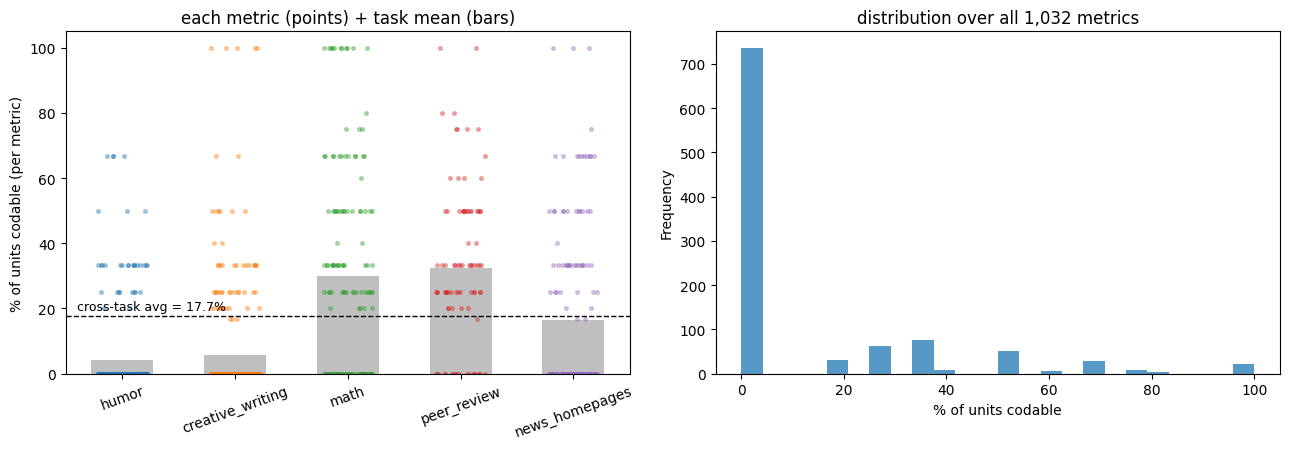

cross-task average % codable: 17.7%


,n_metrics,n_units,mean_pct_codable,pct_fully_uncodable,mean_pct_taste
task,,,,,
humor,284,968,4.2,88.4,30.7
creative_writing,369,1246,5.6,84.8,21.3
math,141,455,29.8,40.4,5.2
peer_review,88,331,32.3,22.7,6.9
news_homepages,150,458,16.4,64.0,10.2


In [2]:
cod = {}
for t in TASKS:
    d = json.load(open(f"{D}/code_metrics/unit_codability_{t}.json"))["metrics"]
    for name, units in d.items():
        labs = [u["label"] for u in units]
        cod[(t, name)] = {"n_units": len(labs),
                          "pct_codable": 100 * sum(l == "MECHANICAL" for l in labs) / len(labs),
                          "pct_taste": 100 * sum(l == "TASTE" for l in labs) / len(labs)}
dfc = pd.DataFrame([{"task": t, "metric": n, **v} for (t, n), v in cod.items()])
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
rng = np.random.default_rng(0)
means = dfc.groupby("task")["pct_codable"].mean().reindex(TASKS)
for i, t in enumerate(TASKS):
    y = dfc[dfc.task == t]["pct_codable"].values
    axes[0].scatter(i + rng.uniform(-.22, .22, len(y)), y, s=7, alpha=.35)
axes[0].bar(range(len(TASKS)), means.values, width=.55, alpha=.25, color="k", zorder=0)
axes[0].axhline(means.mean(), color="k", ls="--", lw=1)
axes[0].text(-.4, means.mean() + 2, f"cross-task avg = {means.mean():.1f}%", fontsize=9)
axes[0].set_xticks(range(len(TASKS))); axes[0].set_xticklabels(TASKS, rotation=20)
axes[0].set_ylabel("% of units codable (per metric)")
axes[0].set_title("each metric (points) + task mean (bars)")
dfc["pct_codable"].plot(kind="hist", bins=24, ax=axes[1], alpha=.75)
axes[1].set_xlabel("% of units codable"); axes[1].set_title("distribution over all 1,032 metrics")
plt.tight_layout(); plt.show()
summ = dfc.groupby("task").agg(n_metrics=("metric", "count"), n_units=("n_units", "sum"),
                               mean_pct_codable=("pct_codable", "mean"),
                               pct_fully_uncodable=("pct_codable", lambda s: 100 * (s == 0).mean()),
                               mean_pct_taste=("pct_taste", "mean")).round(1).reindex(TASKS)
print(f"cross-task average % codable: {means.mean():.1f}%")
summ

## 4.2 Which parts of the prompt matter — every metric, then the mean

Left: per-metric recovery for each text-segment category — **one faint line per metric**, bold line = mean (judge = llama70b; z×a slate constructs, 4 tasks pooled; news excluded from these joins). Right: the same as box plots of the per-metric **gain over the bare name**.

Certified: gains are content not length (`definition_padded` ≈ `definition`), placebo at floor; `name` talkative-but-uninformative, `dossier` decisive-and-efficient (MI census).

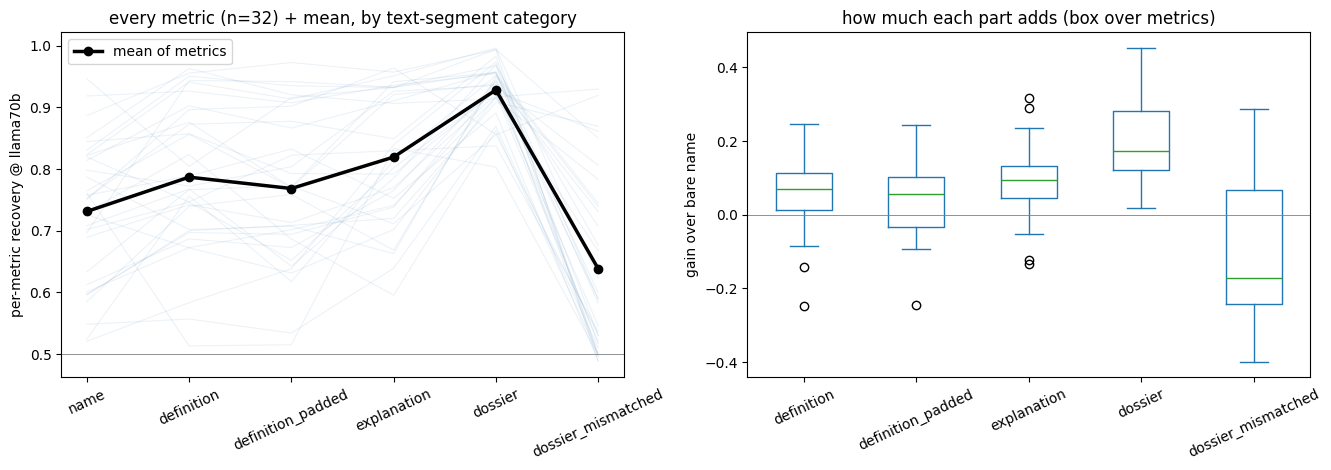

In [3]:
LADDER = ["llama1b","llama3b","qwen25-3b","qwen25-7b","llama8b","qwen25-14b",
          "gemma2-27b","qwen25-32b","llama70b","qwen25-72b"]
PAN = {t: {ex: lp(f"{D}/zxa_panels/mbar_zxa_{t}_{ex}.npz") for ex in LADDER} for t in ZTASKS}
GLMP = {t: {g: lp(f"{D}/zxa_panels/mbar_zxaglm_{t}_{g}.npz") for g in ("glm-47","glm-52")} for t in ZTASKS}
def ref_for(task, base):
    votes = []
    for src in (PAN[task].get("llama70b", {}), PAN[task].get("qwen25-72b", {}),
                GLMP[task].get("glm-47", {}), GLMP[task].get("glm-52", {})):
        r = src.get(base + "||dossier")
        if r is not None: votes.append((np.asarray(r, float) > .5).astype(float))
    if len(votes) < 2: return None
    m = np.nanmean(np.stack(votes), 0)
    return np.where(m > .5, 1, np.where(m < .5, 0, -1))
ARMS = ["name", "definition", "definition_padded", "explanation", "dossier", "dossier_mismatched"]
recs = []
for t in ZTASKS:
    bases = sorted({k.split("||")[0] for k in PAN[t].get("llama70b", {}) if not k.startswith("PLANTED")})
    for b in bases:
        lab = ref_for(t, b)
        if lab is None: continue
        row = {"task": t, "metric": b}
        for arm in ARMS:
            r = PAN[t]["llama70b"].get(f"{b}||{arm}")
            if r is not None:
                y = balanced(np.asarray(r, float), lab)
                if y is not None: row[arm] = y
        if "name" in row and "dossier" in row: recs.append(row)
df42 = pd.DataFrame(recs)
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
xs = range(len(ARMS))
for _, r in df42.iterrows():
    axes[0].plot(xs, [r.get(a, np.nan) for a in ARMS], color="steelblue", alpha=.10, lw=.8)
axes[0].plot(xs, [df42[a].mean() for a in ARMS], color="k", lw=2.5, marker="o", label="mean of metrics")
axes[0].set_xticks(xs); axes[0].set_xticklabels(ARMS, rotation=25); axes[0].axhline(.5, color="gray", lw=.6)
axes[0].set_ylabel("per-metric recovery @ llama70b"); axes[0].legend()
axes[0].set_title(f"every metric (n={len(df42)}) + mean, by text-segment category")
gains = df42[["definition","definition_padded","explanation","dossier","dossier_mismatched"]].sub(df42["name"], axis=0)
gains.plot(kind="box", ax=axes[1], rot=25)
axes[1].axhline(0, color="gray", lw=.6); axes[1].set_ylabel("gain over bare name")
axes[1].set_title("how much each part adds (box over metrics)")
plt.tight_layout(); plt.show()

## 4.2a Examples vs definitions, and the judge-model effect

`definition` = show the written definition. `examples` (`functional`) = show the **name + selected example texts** instead. Wins below are holdout, at the judges that selected the examples; the winners are gestalt 'show-don't-tell' constructs. The three-judge comparison shows the same example sets are a **win** (selector), a **harm** (qwen25-72b, well-calibrated), or a **placebo** (gpt-oss — any examples fix its collapsed definition-reading; swapped examples work equally) — articulation value is a property of the construct–listener pair. Cross-receiver example *content* concentrates in **norm-boundary** metrics (blind-categorized, p=.006/.0095, LOO-robust).

metrics where examples beat the definition by >= .05 (best cell per metric):


,task,judge,definition,examples,delta
metric,,,,,
"Compressed, quotable phrasing",humor,llama70b,0.5511,0.8114,0.260
"Surprise, misdirection, and dual‑read clarity",humor,llama70b,0.6706,0.9059,0.235
"Delivery, timing, and commitment",humor,qwen25-72b,0.7361,0.9618,0.226
"Surprise, incongruity, and misdirection mechanics",humor,llama70b,0.6791,0.9002,0.221
Economy and Precision of Prose,creative_writing,llama70b,0.5718,0.7719,0.200
Observational/everyday‑life humor,humor,llama70b,0.6808,0.8808,0.200
Shared knowledge and reference accessibility,humor,qwen25-72b,0.5728,0.7529,0.180
Concrete imagery and vivid specificity,humor,llama70b,0.7491,0.9239,0.175
Cringe/awkwardness calibrated,humor,llama70b,0.7751,0.9234,0.148


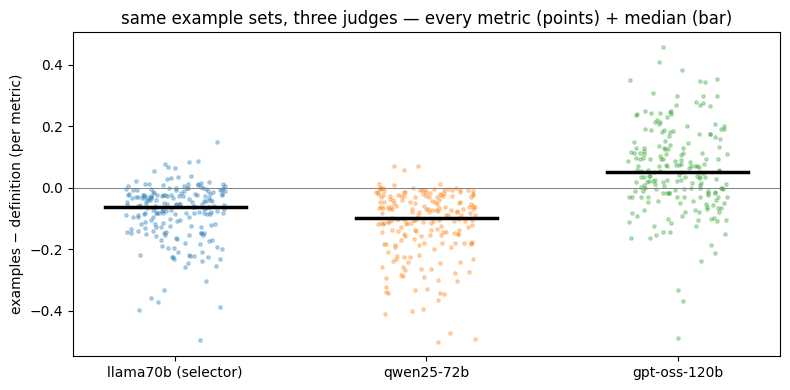

In [4]:
led70 = []
for s in ("llama70b", "qwen25-72b"):
    d = json.load(open(f"{D}/flips/flip_functional_v2_{s}.json"))["results"]
    for task, dd in d.items():
        if task == "news_homepages": continue
        for base, rec in dd.items():
            for obj, po in rec.get("objectives", {}).items():
                if obj == "null": continue
                h = po.get("holdout", {})
                if h.get("functional") is not None and h.get("definition") is not None:
                    led70.append({"task": task, "metric": base, "judge": s,
                                  "definition": h["definition"], "examples": h["functional"],
                                  "delta": round(h["functional"] - h["definition"], 3)})
df70 = pd.DataFrame(led70)
best = (df70.sort_values("delta", ascending=False).groupby("metric").first()
        .sort_values("delta", ascending=False))
print("metrics where examples beat the definition by >= .05 (best cell per metric):")
display(best[best.delta >= .05][["task", "judge", "definition", "examples", "delta"]])
led = json.load(open(f"{D}/analyses/v3sets_ledger_v1.json"))
rows = []
for rcv in ("qwen25-72b", "gpt-oss-120b"):
    for r in led[rcv]:
        rows.append({"judge": rcv, "metric": r["b"],
                     "examples_minus_definition": r["functional"] - r["definition"]})
v3h = json.load(open(f"{D}/flips/flip_functional_v3_llama70b.json"))["results"]["humor"]
for b, rec in v3h.items():
    h = rec["objectives"].get("frontier2v", {}).get("holdout", {})
    if h.get("functional") is not None and h.get("definition") is not None:
        rows.append({"judge": "llama70b (selector)", "metric": b,
                     "examples_minus_definition": h["functional"] - h["definition"]})
dfr = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(8, 4))
order = ["llama70b (selector)", "qwen25-72b", "gpt-oss-120b"]
rng = np.random.default_rng(1)
for i, j in enumerate(order):
    y = dfr[dfr.judge == j]["examples_minus_definition"].values
    ax.scatter(i + rng.uniform(-.2, .2, len(y)), y, s=6, alpha=.3)
    ax.plot([i - .28, i + .28], [np.median(y)] * 2, color="k", lw=2.5)
ax.axhline(0, color="gray", lw=.7); ax.set_xticks(range(3)); ax.set_xticklabels(order)
ax.set_ylabel("examples − definition (per metric)")
ax.set_title("same example sets, three judges — every metric (points) + median (bar)")
plt.tight_layout(); plt.show()

## 4.3 Scaling laws — recovery vs judge capacity, split by saturation group

Full-bank curves from the crowd panels (each metric's own rubric read by every judge; qwen2.5 family shown — most rungs). Groups use the **corrected** saturation measure (the stored RISING/FLAT verdicts came from a retracted slope definition):
- **still gaining ('rising')** — top-vs-mid gain > .02 in ALL 3 families (asymptote unknown; n≈69)
- **plateaued** — gain ≤ .02 in ALL families (capability stopped helping)
- **family-dependent ('saturating')** — gaining in some families only

Each panel: one faint line per metric, bold = mean; dashed overlay = the **examples channel** (flip-ladder functional arm, same-family rungs, restricted to slate metrics in that group — humor/CW/math).

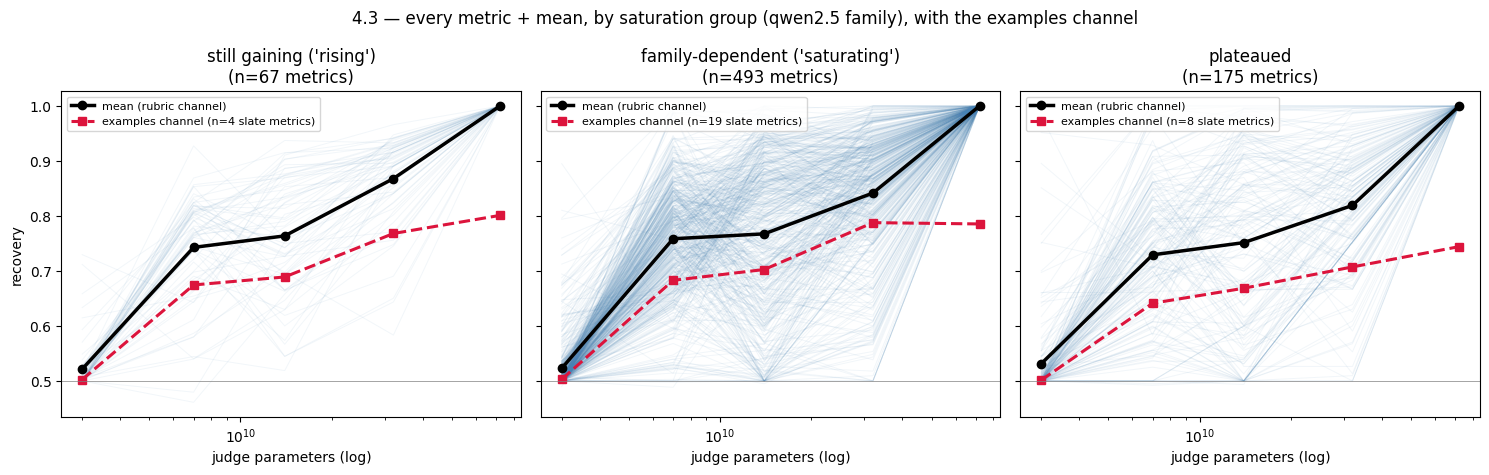

{"still gaining ('rising')": 67, "family-dependent ('saturating')": 493, 'plateaued': 175}


In [5]:
QF = ["qwen25-3b", "qwen25-7b", "qwen25-14b", "qwen25-32b", "qwen25-72b"]
QP = [3e9, 7e9, 14e9, 32e9, 72e9]
def crowd(task, ex):
    d = {}
    if task == "humor":
        d.update(lp(f"{D}/crowd_panels/mbar285_{ex}.npz")); d.update(lp(f"{D}/crowd_panels/mbar2_humor_sup_{ex}.npz"))
    else:
        d.update(lp(f"{D}/crowd_panels/mbar2_{task}_{ex}.npz"))
    return d
CR = {t: {ex: crowd(t, ex) for ex in QF + ["llama70b"]} for t in TASKS}
def cref(task, base):
    votes = []
    for ex in ("llama70b", "qwen25-72b"):
        r = CR[task].get(ex, {}).get(base)
        if r is not None: votes.append((np.asarray(r, float) > .5).astype(float))
    if len(votes) < 2: return None
    m = np.stack(votes).mean(0)
    return np.where(m > .5, 1, np.where(m < .5, 0, -1))
fj = json.load(open(f"{D}/analyses/family_verdict_join_v1.json"))["full_rows"]
def group_of(r, t=.02):
    tm = [v for v in r["top_minus_mid"].values() if v is not None]
    if len(tm) < 3: return None
    if all(v > t for v in tm): return "still gaining ('rising')"
    if all(v <= t for v in tm): return "plateaued"
    return "family-dependent ('saturating')"
GROUP = {(r["task"], r["name"]): group_of(r) for r in fj}
curves = {}
for r in fj:
    t, b = r["task"], r["name"]
    g = GROUP[(t, b)]
    if g is None: continue
    lab = cref(t, b)
    if lab is None: continue
    ys = []
    for ex in QF:
        v = CR[t].get(ex, {}).get(b)
        ys.append(balanced(np.asarray(v, float), lab) if v is not None else None)
    if sum(y is not None for y in ys) >= 4:
        curves.setdefault(g, []).append((t, b, ys))
# examples channel from the flip ladder (same qwen rungs), per group
lad = {ex: lp(f"{D}/flips/mbar_flipladder_{ex}.npz") for ex in QF}
mask = json.load(open(f"{D}/flips/flipladder_mask_v1.json"))
ex_curves = {}
for key in lad[QF[-1]]:
    if "functional_llama70b_frontier" not in key: continue
    t, rest = key.split("|", 1)
    b = rest.split("||")[0]
    g = GROUP.get((t, b))
    if g is None or t not in ZTASKS: continue
    lab = ref_for(t, b) if t in ZTASKS else None
    if lab is None: continue
    ys = []
    for ex in QF:
        r = lad[ex].get(key)
        ys.append(balanced(np.asarray(r, float), lab) if r is not None else None)
    if sum(y is not None for y in ys) >= 4:
        ex_curves.setdefault(g, []).append(ys)
GORDER = ["still gaining ('rising')", "family-dependent ('saturating')", "plateaued"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8), sharey=True)
for ax, g in zip(axes, GORDER):
    cs = curves.get(g, [])
    for t, b, ys in cs:
        xs = [p for p, y in zip(QP, ys) if y is not None]
        vy = [y for y in ys if y is not None]
        ax.semilogx(xs, vy, color="steelblue", alpha=.07, lw=.7)
    mean = [np.mean([ys[i] for _, _, ys in cs if ys[i] is not None]) for i in range(len(QF))]
    ax.semilogx(QP, mean, color="k", lw=2.5, marker="o", label="mean (rubric channel)")
    ec = ex_curves.get(g, [])
    if ec:
        em = [np.mean([ys[i] for ys in ec if ys[i] is not None]) for i in range(len(QF))]
        ax.semilogx(QP, em, color="crimson", lw=2.2, ls="--", marker="s",
                    label=f"examples channel (n={len(ec)} slate metrics)")
    ax.set_title(f"{g}\n(n={len(cs)} metrics)"); ax.axhline(.5, color="gray", lw=.5)
    ax.set_xlabel("judge parameters (log)"); ax.legend(fontsize=8)
axes[0].set_ylabel("recovery")
fig.suptitle("4.3 — every metric + mean, by saturation group (qwen2.5 family), with the examples channel")
plt.tight_layout(); plt.show()
print({g: len(curves.get(g, [])) for g in GORDER})

---
### Canonical artifacts (quote these, not notebook recomputations)
| claim | artifact |
|---|---|
| per-metric unit codability (this build) | `code_metrics/unit_codability_{task}.json` (blind, 6/6 anchors ×3 annotators) |
| channel economics (MI/degeneracy) | `analyses/mi_upper_census_v1.json`, `_v2.json` |
| examples ledgers (never merged) | `flips/flip_functional_v2_*.json` · `analyses/v3sets_ledger_v1.json` + `metric_categories_blind_v1.json` |
| frontier limit cells | `analyses/frontier_limit_humor_v2.json` · math corroboration `analyses/glmexmath_harvest_v1.json` |
| examples-over-capacity | `analyses/flipladder_curve_v2_nonews.json` |
| staircases / census / de-censor | `analyses/family_verdict_join_v1.json`, `saturation_census_curve_v1.json`, `decensor_harvest_v1.json` |

Narrative + phrasing law: `notes/2026-08-05__direction12-battery-plan.md`.